# Paper figures — PyTorch vs JAX (alphagenome_ft), probing vs LoRA

Cross-checks the AlphaGenome-PyTorch splicing finetune (`figures/paper.ipynb`) against the JAX/`alphagenome_ft` port (`workflows/10-jax_finetuning/`), evaluated on xinming's rerun checkpoints (`results/xinming/alphagenome_finetuning_downstream_2026-08-31/`, since local JAX finetuning on this cluster was too slow). Same three figures as `paper.ipynb` (gene expression, splice site usage, splice junctions), but four models instead of two AlphaGenome + two Pangolin: **AlphaGenome-PyTorch** and **AlphaGenome-JAX**, each **probing** (linear-probe) and **LoRA** — no Pangolin here.

## imports

In [1]:
import os
import textwrap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from figutils import cm, set_figure_style

set_figure_style()

PAL_MODELS = {
    # Local PyTorch runs (this repo's own finetuning + evaluation)
    "AlphaGenome-PyTorch, local (probing)":                 "#717EC3",
    "AlphaGenome-PyTorch, local (LoRA)":                    "#4C956C",
    # Xinming's PyTorch continuation of the same two runs on their cluster --
    # LoRA is a strictly less-trained snapshot (epoch 7/10, partial) than the
    # local LoRA run above (epoch 10); labeled explicitly, never compared as
    # same-epoch.
    "AlphaGenome-PyTorch, xinming (probing)":               "#F4A261",
    "AlphaGenome-PyTorch, xinming (LoRA, epoch7 partial)":  "#9D4EDD",
    # JAX/alphagenome_ft reproduction, evaluated against xinming's JAX checkpoints
    "AlphaGenome-JAX (probing)":                            "#B08968",
    "AlphaGenome-JAX (LoRA)":                                "#D62839",
}

# Sample shown as an alpha/tone modifier on top of the model color: WT first (higher
# alpha, more opaque), K700E second (lower alpha, lighter).
SAMPLE_ORDER = ["WT", "K700E"]
SAMPLE_ALPHA = {"WT": 1.0, "K700E": 0.55}


In [2]:
# Target on-figure width per bar (in cm) -- fixed across all plots so bar width is
# consistent regardless of how many models/bars a given figure has; plot width is
# derived from this instead of a fixed aspect, so plots with more bars (e.g. SSU,
# which compares 4 models) come out proportionally wider rather than more cramped.
BAR_WIDTH_CM = 0.6
XTICK_WRAP_WIDTH = 12
# Minimum bar height (in y-axis units, e.g. Pearson r) for the rotated "n=" label to
# fit inside the bar; shorter bars get the label stacked above instead.
MIN_BAR_HEIGHT_FOR_INSIDE_LABEL = 0.15


def plot_setting_bars(data, x_col, x_order, x_labels, y_col, title, outfile,
                       ylabel, models, model_palette=PAL_MODELS,
                       row=None, row_order=None, row_labels=None,
                       rotate_value_labels=True, aspect=None, height=4 * cm):
    """Bar plot faceted by evaluation setting (x-axis).

    Model is the main color; sample (WT/K700E) modifies alpha within each model's
    bar (WT more opaque, K700E lighter). Produces two separate legends: one for
    model color, one for sample alpha. Each bar is annotated with its Pearson r
    above it, and its n vertically near the bottom -- unless the bar is too short
    to fit it, in which case n is stacked further above the bar (clear of the
    Pearson r label) instead. If `ci_lo`/`ci_hi` columns are present, draws a
    bootstrap error bar (2.5/97.5 percentile, 95% CI) on top of each bar.
    """
    data = data.copy()
    combined_order = ["{}__{}".format(m, s) for m in models for s in SAMPLE_ORDER]
    combined_to_sample = {"{}__{}".format(m, s): s for m in models for s in SAMPLE_ORDER}
    combined_palette = {"{}__{}".format(m, s): model_palette[m] for m in models for s in SAMPLE_ORDER}
    data["combined"] = data["model"] + "__" + data["sample"]
    has_n = "n" in data.columns
    has_ci = "ci_lo" in data.columns and "ci_hi" in data.columns

    if aspect is None:
        total_bars = len(x_order) * len(models) * len(SAMPLE_ORDER)
        aspect = (total_bars * BAR_WIDTH_CM * cm) / height

    g = sns.catplot(
        data=data,
        kind="bar",
        x=x_col, y=y_col,
        order=x_order,
        hue="combined", hue_order=combined_order, palette=combined_palette,
        row=row, row_order=row_order,
        width=0.7,
        height=height,
        aspect=aspect,
        legend=False,
        edgecolor="black",
        linewidth=0.5,
    )
    g.set_axis_labels("", ylabel)
    g.set_xticklabels([textwrap.fill(lbl, XTICK_WRAP_WIDTH) for lbl in x_labels])
    if row is not None:
        if row_labels is not None:
            g.set_titles("")
            for ax, row_val in zip(g.axes.flat, row_order):
                ax.set_title(row_labels[row_val])
        else:
            g.set_titles("{row_name}")

    value_rotation = 90 if rotate_value_labels else 0
    row_values = row_order if row is not None else [None]
    for ax, row_val in zip(g.axes.flat, row_values):
        ax_data = data if row_val is None else data[data[row] == row_val]
        # snapshot before the loop -- ax.errorbar() below appends its own container
        # to ax.containers, and that list is live, so iterating it directly would
        # keep growing mid-loop and desync hue_idx from combined_order.
        bar_containers = list(ax.containers)
        for hue_idx, container in enumerate(bar_containers):
            combined_key = combined_order[hue_idx]
            sample = combined_to_sample[combined_key]
            text_color = "white" if SAMPLE_ALPHA[sample] >= 0.8 else "black"
            # seaborn only draws a bar for (x, hue) combos that actually have data --
            # when a setting is empty for this hue (e.g. no K700E rows under
            # "wt_specific"), the container has fewer bars than len(x_order), so
            # bar_idx must be matched against the x-values that actually have data
            # for this hue, not against x_order directly.
            present_x = [
                xv for xv in x_order
                if not ax_data[(ax_data[x_col] == xv) & (ax_data["combined"] == combined_key)].empty
            ]
            for bar_idx, bar in enumerate(container):
                bar.set_alpha(SAMPLE_ALPHA[sample])
                h = bar.get_height()
                if not np.isfinite(h):
                    continue
                cx = bar.get_x() + bar.get_width() / 2
                if has_ci and bar_idx < len(present_x):
                    x_val = present_x[bar_idx]
                    row_match = ax_data[(ax_data[x_col] == x_val) & (ax_data["combined"] == combined_key)]
                    if len(row_match):
                        ci_lo = row_match["ci_lo"].values[0]
                        ci_hi = row_match["ci_hi"].values[0]
                        if pd.notna(ci_lo) and pd.notna(ci_hi):
                            yerr = [[max(h - ci_lo, 0)], [max(ci_hi - h, 0)]]
                            ax.errorbar(cx, h, yerr=yerr, fmt="none", ecolor="black",
                                        elinewidth=0.6, capsize=1.5, capthick=0.6)
                ax.text(cx, h + 0.02, "{:.3f}".format(h), ha="center", va="bottom",
                        fontsize=5, rotation=value_rotation)
                if has_n and bar_idx < len(present_x):
                    x_val = present_x[bar_idx]
                    row_match = ax_data[(ax_data[x_col] == x_val) & (ax_data["combined"] == combined_key)]
                    if len(row_match):
                        n = int(row_match["n"].values[0])
                        if h >= MIN_BAR_HEIGHT_FOR_INSIDE_LABEL:
                            ax.text(cx, 0.02, "n={:,}".format(n), ha="center", va="bottom",
                                    fontsize=4, rotation=90, color=text_color)
                        else:
                            ax.text(cx, h + 0.18, "n={:,}".format(n), ha="center", va="bottom",
                                    fontsize=4, rotation=value_rotation, color="black")

    model_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=model_palette[m], edgecolor="black", linewidth=0.5)
        for m in models
    ]
    sample_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="black", alpha=SAMPLE_ALPHA[s], edgecolor="black", linewidth=0.5)
        for s in SAMPLE_ORDER
    ]
    legend_model = g.figure.legend(
        model_handles, models, title="Model", loc="upper left",
        bbox_to_anchor=(1.0, 0.9), frameon=False, fontsize=5, title_fontsize=6,
    )
    g.figure.add_artist(legend_model)
    g.figure.legend(
        sample_handles, SAMPLE_ORDER, title="Sample", loc="upper left",
        bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=5, title_fontsize=6,
    )
    g.figure.subplots_adjust(right=0.78)
    g.figure.suptitle(title, y=1.04)
    g.figure.savefig(outfile, bbox_inches="tight")
    plt.show()
    print("saved:", outfile)

## data

Predictions dirs point straight at each run's `predictions/` output (not `eval_dir/run_name/epoch{N}/subset` reconstruction, since the JAX runs only ever evaluated one checkpoint each, not an epoch series). Metrics are precomputed by `workflows/09-submission/scripts/prepare_paper_metrics_jax.py` (same computations as `prepare_paper_metrics.py`, generalized to take explicit predictions dirs) into `results/paper/{gene_expr,ssu,junc}_metrics_jax.parquet` — re-run that script after a new evaluation run instead of recomputing here.

In [3]:
ROOT = ".."

# Predictions dirs behind each PAL_MODELS entry -- see
# workflows/10-jax_finetuning/rules/paper.smk (or workflows/11-.../rules/paper.smk,
# a duplicate of the same rules) for the actual --extra-model wiring that produces
# results/paper/*_metrics_jax.parquet below. Kept here for reference only; this
# notebook itself just reads the precomputed metrics parquets.
MODEL_PRED_DIRS = {
    "AlphaGenome-PyTorch, local (probing)": os.path.join(
        ROOT, "results", "bsc", "evaluation", "alphagenome_pytorch", "full",
        "randinit__newloss__annotated__frozen__multigpu_ddp", "epoch10", "test", "predictions"),
    "AlphaGenome-PyTorch, local (LoRA)": os.path.join(
        ROOT, "results", "evaluation", "alphagenome_pytorch", "full",
        "randinit__newloss__annotated__lora__largegpu__nowarmup", "epoch10", "test", "predictions"),
    "AlphaGenome-PyTorch, xinming (probing)": os.path.join(
        ROOT, "results", "evaluation", "alphagenome_pytorch_xinming", "full",
        "randinit__newloss__annotated__frozen__multigpu_ddp", "epoch10", "test", "predictions"),
    "AlphaGenome-PyTorch, xinming (LoRA, epoch7 partial)": os.path.join(
        ROOT, "results", "evaluation", "alphagenome_pytorch_xinming", "full",
        "randinit__newloss__annotated__lora__largegpu__nowarmup", "epoch7", "test", "predictions"),
    "AlphaGenome-JAX (probing)": os.path.join(
        ROOT, "results", "evaluation", "alphagenome_ft", "full",
        "randinit__annotated__frozen__probing_jax", "test", "predictions"),
    "AlphaGenome-JAX (LoRA)": os.path.join(
        ROOT, "results", "evaluation", "alphagenome_ft", "full",
        "randinit__annotated__frozen__lora_jax", "test", "predictions"),
}

OUTPUT_DIR = os.path.join("pdfs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODELS = list(PAL_MODELS.keys())

SAMPLE_LABELS = {
    "SRR17111303": "WT",
    "SRR17111311": "K700E",
}
SAMPLE_ID_OF = {v: k for k, v in SAMPLE_LABELS.items()}


## figures

### Gene expression evaluation

Rows facet by resolution (1bp on top, 32bp below). x-axis is the evaluation setting:
- **Profile: mean per interval** — per-interval Pearson r (Borzoi-style central crop), averaged across test intervals. Error bars: 2.5/97.5 percentile (95%) bootstrap CI resampling per-interval r's (100 reps).
- **Profile: accumulated** — pooled Pearson r over all central-crop positions concatenated across test intervals. No bootstrap CI: computed from streaming sufficient statistics only, so no error bars are shown.
- **Gene: mean exonic coverage** — per-gene Pearson r on mean log exon coverage. Error bars: 2.5/97.5 percentile (95%) bootstrap CI resampling genes (100 reps).

Model (PyTorch/JAX × probing/LoRA) is the bar color; sample (WT/K700E) is the alpha/tone.

In [4]:
GENE_EXPR_SETTINGS = ["profile_per_interval", "profile_accumulated", "gene_mean_exonic"]
GENE_EXPR_LABELS = {
    "profile_per_interval": "Profile: mean per interval",
    "profile_accumulated":  "Profile: accumulated",
    "gene_mean_exonic":     "Gene: mean exonic coverage",
}
RESOLUTIONS = ["1bp", "32bp"]

gene_expr_metrics = pd.read_parquet(os.path.join(ROOT, "results", "paper", "gene_expr_metrics_jax.parquet"))
print(gene_expr_metrics)


   sample  pearson_r           n resolution     ci_lo     ci_hi  \
0      WT   0.513791        7989        1bp  0.507743  0.522080   
1   K700E   0.470890        8844        1bp  0.463859  0.477806   
2      WT   0.823772  2500460544        1bp       NaN       NaN   
3   K700E   0.814992  2500460544        1bp       NaN       NaN   
4      WT   0.901071        6631        1bp  0.894065  0.907419   
..    ...        ...         ...        ...       ...       ...   
67  K700E   0.453824        8844       32bp  0.446597  0.460878   
68     WT   0.746602    78139392       32bp       NaN       NaN   
69  K700E   0.739859    78139392       32bp       NaN       NaN   
70     WT   0.824714        6631       32bp  0.814256  0.833730   
71  K700E   0.829453        6631       32bp  0.818879  0.838715   

                                   model               setting  \
0   AlphaGenome-PyTorch, local (probing)  profile_per_interval   
1   AlphaGenome-PyTorch, local (probing)  profile_per_interval 

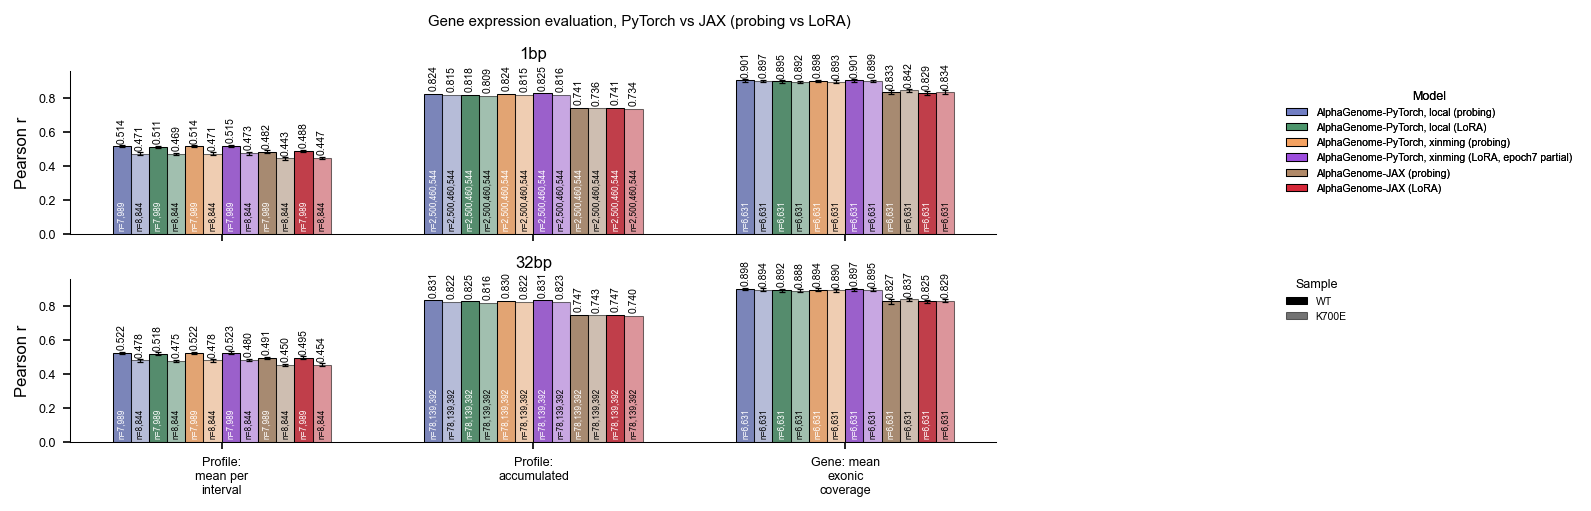

saved: pdfs/fig1_jax_gene_expression.pdf


In [5]:
plot_setting_bars(
    data=gene_expr_metrics,
    x_col="setting", x_order=GENE_EXPR_SETTINGS,
    x_labels=[GENE_EXPR_LABELS[s] for s in GENE_EXPR_SETTINGS],
    y_col="pearson_r",
    title="Gene expression evaluation, PyTorch vs JAX (probing vs LoRA)",
    outfile=os.path.join(OUTPUT_DIR, "fig1_jax_gene_expression.pdf"),
    ylabel="Pearson r",
    models=MODELS,
    row="resolution", row_order=RESOLUTIONS,
)


### Splice site usage (SSU)

Restricted to splice sites common to all four models' test-interval predictions. Sites covered by more than one overlapping test interval keep only the prediction from the window that best centers the site (max distance to both window edges), rather than averaging across windows. Split into two figures:
- **fig2a (general)** — all common sites (regardless of per-condition usage).
- **fig2b (shared vs condition-specific)** — three settings, all mutually exclusive partitions of the general set by observed usage: shared sites (usage > 0 in both WT and K700E), WT-specific sites (usage > 0 in WT, 0 in K700E), and K700E-specific sites (usage > 0 in K700E, 0 in WT).

Model is the bar color; sample (WT/K700E) is the alpha/tone. Error bars: 2.5/97.5 percentile (95%) bootstrap CI (100 reps, resampling sites with replacement).

In [6]:
SSU_SETTINGS = ["general", "shared", "wt_specific", "k700e_specific"]
SSU_LABELS = {
    "general":        "General",
    "shared":         "Shared splice sites",
    "wt_specific":    "WT-specific sites",
    "k700e_specific": "K700E-specific sites",
}

ssu_metrics = pd.read_parquet(os.path.join(ROOT, "results", "paper", "ssu_metrics_jax.parquet"))
print(ssu_metrics)


   sample  pearson_r      n  \
0      WT   0.712863  41821   
1   K700E   0.583221  45090   
2      WT   0.690393  34740   
3   K700E   0.521199  34740   
4      WT   0.423037   7081   
5   K700E   0.105059  10350   
6      WT   0.726877  41821   
7   K700E   0.588769  45090   
8      WT   0.707060  34740   
9   K700E   0.529636  34740   
10     WT   0.429502   7081   
11  K700E   0.089838  10350   
12     WT   0.718564  41821   
13  K700E   0.586939  45090   
14     WT   0.696906  34740   
15  K700E   0.525371  34740   
16     WT   0.428069   7081   
17  K700E   0.106774  10350   
18     WT   0.700746  41821   
19  K700E   0.586168  45090   
20     WT   0.676432  34740   
21  K700E   0.527378  34740   
22     WT   0.404149   7081   
23  K700E   0.092521  10350   
24     WT   0.617125  41821   
25  K700E   0.494260  45090   
26     WT   0.584131  34740   
27  K700E   0.429835  34740   
28     WT   0.339515   7081   
29  K700E   0.084136  10350   
30     WT   0.635016  41821   
31  K700

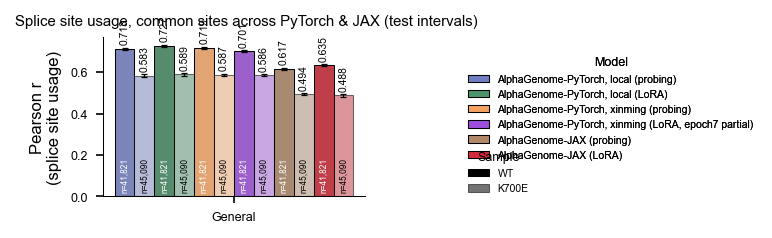

saved: pdfs/fig2a_jax_ssu_general.pdf


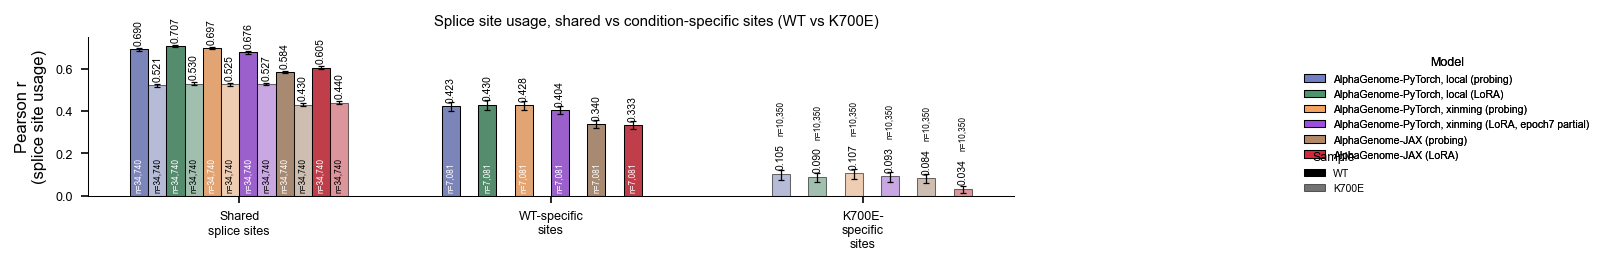

saved: pdfs/fig2b_jax_ssu_specific.pdf


In [7]:
plot_setting_bars(
    data=ssu_metrics[ssu_metrics["setting"] == "general"],
    x_col="setting", x_order=["general"],
    x_labels=[SSU_LABELS["general"]],
    y_col="pearson_r",
    title="Splice site usage, common sites across PyTorch & JAX (test intervals)",
    outfile=os.path.join(OUTPUT_DIR, "fig2a_jax_ssu_general.pdf"),
    ylabel="Pearson r\n(splice site usage)",
    models=MODELS,
)

plot_setting_bars(
    data=ssu_metrics[ssu_metrics["setting"].isin(["shared", "wt_specific", "k700e_specific"])],
    x_col="setting", x_order=["shared", "wt_specific", "k700e_specific"],
    x_labels=[SSU_LABELS[s] for s in ["shared", "wt_specific", "k700e_specific"]],
    y_col="pearson_r",
    title="Splice site usage, shared vs condition-specific sites (WT vs K700E)",
    outfile=os.path.join(OUTPUT_DIR, "fig2b_jax_ssu_specific.pdf"),
    ylabel="Pearson r\n(splice site usage)",
    models=MODELS,
)


### Splice junction counts

Junctions covered by more than one overlapping test interval keep only the prediction from the window that best centers both breakpoints, rather than averaging across windows. Split into two figures, mirroring the SSU split above:
- **fig3a (general)** — all junctions with observed count > 0.
- **fig3b (shared vs condition-specific)** — shared junctions (observed count > 0 in both WT and K700E), WT-specific, and K700E-specific junctions (observed count > 0 in one sample, 0 in the other).

Error bars: 2.5/97.5 percentile (95%) bootstrap CI (100 reps, resampling junctions with replacement).

In [8]:
JUNC_SETTINGS = ["general", "shared", "wt_specific", "k700e_specific"]
JUNC_LABELS = {
    "general":        "General",
    "shared":         "Shared junctions",
    "wt_specific":    "WT-specific junctions",
    "k700e_specific": "K700E-specific junctions",
}

junc_metrics = pd.read_parquet(os.path.join(ROOT, "results", "paper", "junc_metrics_jax.parquet"))
print(junc_metrics)


   sample  pearson_r      n  \
0      WT   0.778754  30364   
1   K700E   0.786440  33089   
2      WT   0.766327  22455   
3   K700E   0.762799  22455   
4      WT   0.172404   7909   
5   K700E   0.053542  10634   
6      WT   0.802571  30364   
7   K700E   0.809073  33089   
8      WT   0.788143  22455   
9   K700E   0.785831  22455   
10     WT   0.238899   7909   
11  K700E   0.056830  10634   
12     WT   0.759765  30364   
13  K700E   0.767157  33089   
14     WT   0.747152  22455   
15  K700E   0.742710  22455   
16     WT   0.158902   7909   
17  K700E   0.035940  10634   
18     WT   0.773974  30364   
19  K700E   0.780529  33089   
20     WT   0.758837  22455   
21  K700E   0.754310  22455   
22     WT   0.157698   7909   
23  K700E   0.031181  10634   
24     WT   0.847874  30248   
25  K700E   0.851768  32965   
26     WT   0.834723  22376   
27  K700E   0.832504  22376   
28     WT   0.289370   7872   
29  K700E   0.073356  10589   
30     WT   0.849833  30248   
31  K700

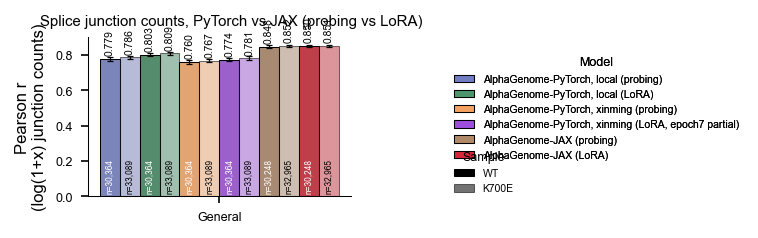

saved: pdfs/fig3a_jax_junctions_general.pdf


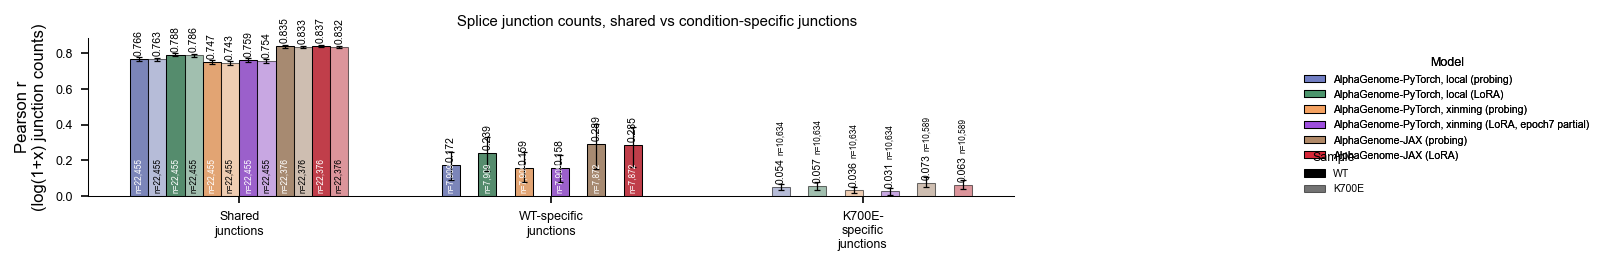

saved: pdfs/fig3b_jax_junctions_specific.pdf


In [9]:
plot_setting_bars(
    data=junc_metrics[junc_metrics["setting"] == "general"],
    x_col="setting", x_order=["general"],
    x_labels=[JUNC_LABELS["general"]],
    y_col="pearson_r",
    title="Splice junction counts, PyTorch vs JAX (probing vs LoRA)",
    outfile=os.path.join(OUTPUT_DIR, "fig3a_jax_junctions_general.pdf"),
    ylabel="Pearson r\n(log(1+x) junction counts)",
    models=MODELS,
)

plot_setting_bars(
    data=junc_metrics[junc_metrics["setting"].isin(["shared", "wt_specific", "k700e_specific"])],
    x_col="setting", x_order=["shared", "wt_specific", "k700e_specific"],
    x_labels=[JUNC_LABELS[s] for s in ["shared", "wt_specific", "k700e_specific"]],
    y_col="pearson_r",
    title="Splice junction counts, shared vs condition-specific junctions",
    outfile=os.path.join(OUTPUT_DIR, "fig3b_jax_junctions_specific.pdf"),
    ylabel="Pearson r\n(log(1+x) junction counts)",
    models=MODELS,
)
